### Importing Libraries :


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading data set

In [2]:
df=pd.read_csv("air-quality-india.csv")
df

,Timestamp,Year,Month,Day,Hour,PM2.5
0,2017-11-07 12:00:00,2017,11,7,12,64.51
1,2017-11-07 13:00:00,2017,11,7,13,69.95
2,2017-11-07 14:00:00,2017,11,7,14,92.79
3,2017-11-07 15:00:00,2017,11,7,15,109.66
4,2017-11-07 16:00:00,2017,11,7,16,116.50
...,...,...,...,...,...,...
36187,2022-06-04 11:00:00,2022,6,4,11,35.89
36188,2022-06-04 12:00:00,2022,6,4,12,33.83
36189,2022-06-04 13:00:00,2022,6,4,13,33.05
36190,2022-06-04 14:00:00,2022,6,4,14,35.29


### Check missing values

In [4]:
df.isnull().sum()

Timestamp    0
Year         0
Month        0
Day          0
Hour         0
PM2.5        0
dtype: int64

### Check Duplicate Rows

In [16]:
df.duplicated().sum()

np.int64(0)

### Check Data Types
* shows every column data type

In [17]:
df.dtypes

Timestamp     object
Year           int64
Month          int64
Day            int64
Hour           int64
PM2.5        float64
dtype: object

### Data Analysis:

### Find Maximum PM2.5 
* "It is used as a reference value to study and analyze air pollution trends over time."

In [18]:
df['PM2.5'].max()

245.63

### Find minimum PM2.5
* we can find minimum PM2.5 value to know the lowest level of air pollution recorded in the data set

In [19]:
df['PM2.5'].min()

7.02

### Statistical Summary:

In [20]:
df.describe()

,Year,Month,Day,Hour,PM2.5
count,36192.000000,36192.000000,36192.000000,36192.000000,36192.000000
mean,2019.682278,6.331841,15.716401,11.477840,49.308429
std,1.345011,3.593321,8.859769,6.925088,24.863511
min,2017.000000,1.000000,1.000000,0.000000,7.020000
25%,2019.000000,3.000000,8.000000,5.000000,28.080000
50%,2020.000000,6.000000,16.000000,11.000000,45.730000
75%,2021.000000,10.000000,23.000000,17.000000,64.520000
max,2022.000000,12.000000,31.000000,23.000000,245.630000


### Year wise Average PM2.5:
* Here we will come to know which is the most effected year

In [21]:
df.groupby('Year')['PM2.5'].mean()

Year
2017    95.064160
2018    54.468449
2019    49.511273
2020    42.386302
2021    44.850633
2022    50.025717
Name: PM2.5, dtype: float64

### Month wise Average PM2.5:

In [22]:
df.groupby('Month')['PM2.5'].mean()

Month
1     75.762716
2     61.233323
3     51.568116
4     42.961583
5     36.068882
6     28.926157
7     22.461443
8     21.525650
9     24.627094
10    47.602640
11    73.918083
12    78.073387
Name: PM2.5, dtype: float64

### Day-Wise Trend:

In [23]:
df.groupby('Day')['PM2.5'].mean()

Day
1     49.687282
2     49.573699
3     48.440537
4     48.984712
5     49.640774
6     49.558032
7     49.389150
8     50.951376
9     51.713174
10    50.716523
11    50.212031
12    49.831619
13    49.775209
14    49.806715
15    48.369617
16    48.579875
17    49.224871
18    49.059259
19    49.743947
20    49.675198
21    49.962021
22    47.189337
23    47.313795
24    48.780457
25    49.340100
26    49.311593
27    47.837704
28    49.194572
29    48.078250
30    48.395346
31    50.888586
Name: PM2.5, dtype: float64

### Peak pollution Hour:

In [24]:
df.groupby('Hour')['PM2.5'].mean().sort_values(ascending=False)

Hour
18    56.547082
19    56.456744
17    56.105450
20    54.766382
5     54.103601
4     53.420826
16    53.412522
21    53.090369
6     51.906999
22    51.545494
3     51.026848
23    50.098299
15    49.416037
7     49.220218
0     48.590989
2     48.563274
1     47.876001
8     46.540518
14    44.298564
9     43.898124
10    41.906830
13    40.534937
11    40.388280
12    39.802929
Name: PM2.5, dtype: float64

### Percentage of High Pollution Records:
* How much % of time air pollution was high / unhealthy

In [25]:
(len(df[df['PM2.5'] > df['PM2.5'].mean()]) / len(df)) * 100

44.869031830238725

### Year wise PM2.5 trend(Line-plot):

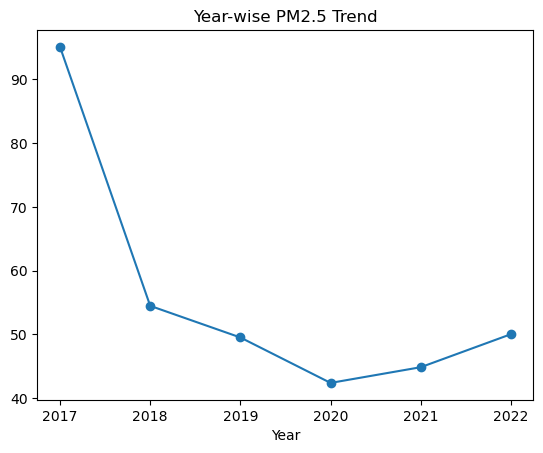

In [26]:
df.groupby('Year')['PM2.5'].mean().plot(marker='o')
plt.title("Year-wise PM2.5 Trend")
plt.show()

### Year-wise comparison bar chart:

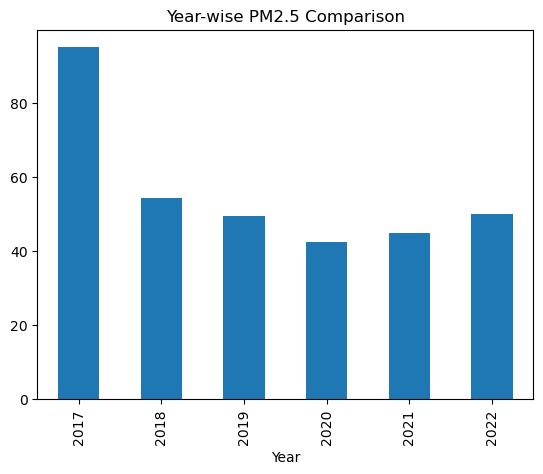

In [27]:
df.groupby('Year')['PM2.5'].mean().plot(kind='bar')
plt.title("Year-wise PM2.5 Comparison")
plt.show()

### Monthly PM2.5 Trend visualization:

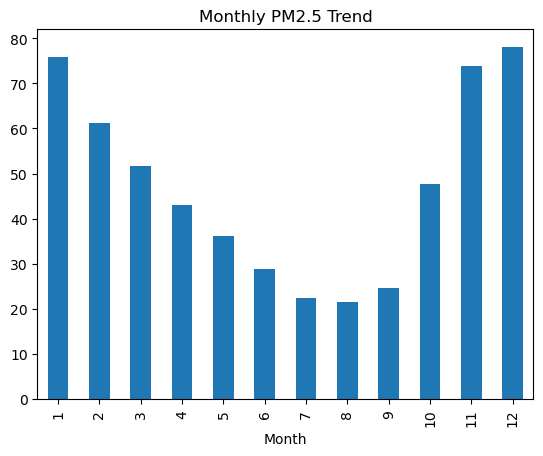

In [28]:
df.groupby('Month')['PM2.5'].mean().plot(kind='bar')
plt.title("Monthly PM2.5 Trend")
plt.show()

### Year vs Month trend :
* This query is used to study how PM2.5 pollution changes across months in different years.

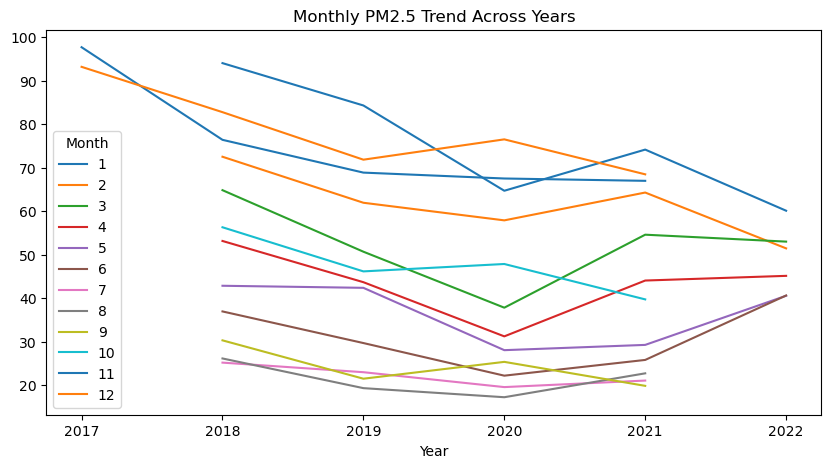

In [29]:
df.groupby(['Year','Month'])['PM2.5'].mean().unstack().plot(figsize=(10,5))
plt.title("Monthly PM2.5 Trend Across Years")
plt.show()

### Hour-wise pollution visualization:

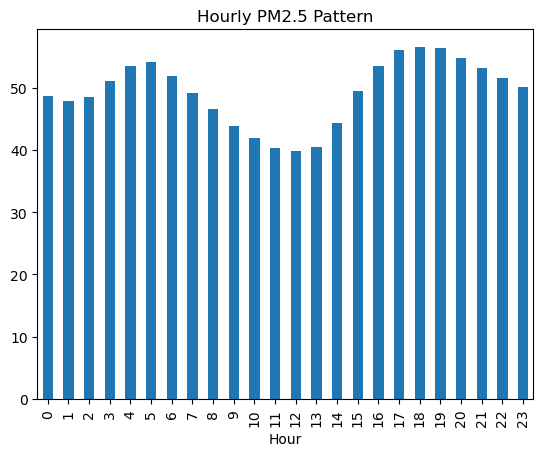

In [30]:
df.groupby('Hour')['PM2.5'].mean().plot(kind='bar')
plt.title("Hourly PM2.5 Pattern")
plt.show()

### Scatter plot :

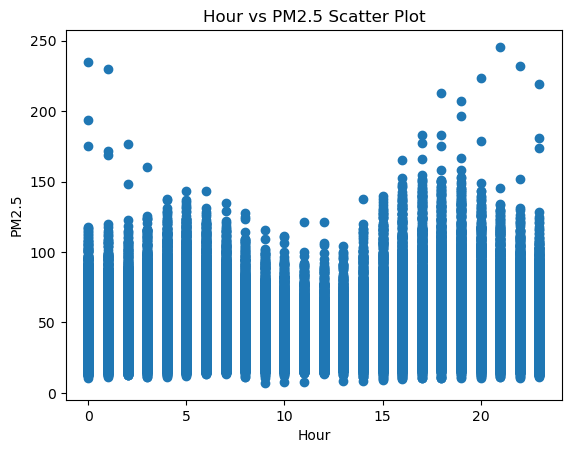

In [37]:
plt.scatter(df['Hour'], df['PM2.5'])
plt.title("Hour vs PM2.5 Scatter Plot")
plt.xlabel("Hour")
plt.ylabel("PM2.5")
plt.show()

### Distribution of PM2.5:
* Tells pollution spread

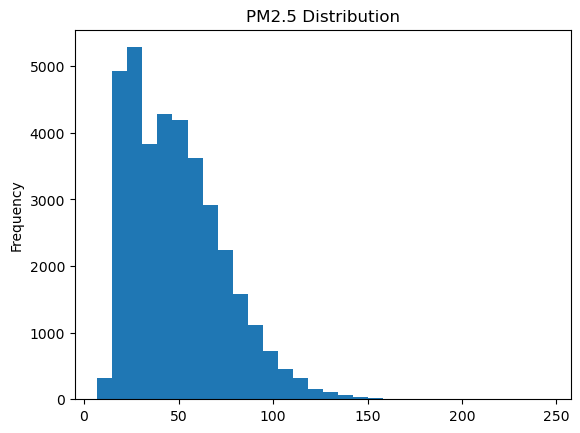

In [31]:
df['PM2.5'].plot(kind='hist', bins=30)
plt.title("PM2.5 Distribution")
plt.show()

### Outlier Detection:
* “Outlier detection is used to identify abnormal PM2.5 values which are significantly higher or lower than normal range. These values may indicate unusual pollution events or data errors.”

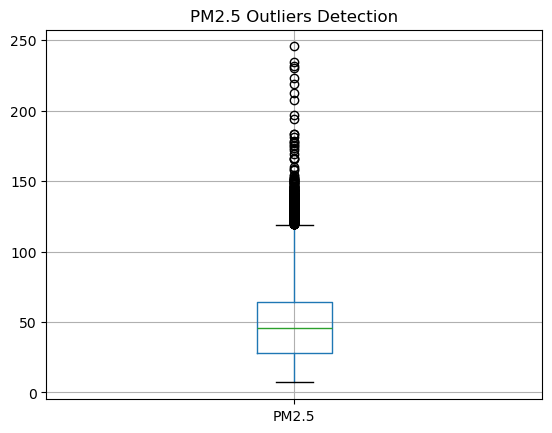

In [32]:
df.boxplot(column='PM2.5')
plt.title("PM2.5 Outliers Detection")
plt.show()

### Correlation check:
* “Correlation analysis is used to find the relationship between variables. It shows how strongly time-based features like year, month, hour are related to PM2.5 pollution levels.”

In [33]:
df[['Year','Month','Day','Hour','PM2.5']].corr()

,Year,Month,Day,Hour,PM2.5
Year,1.000000,-0.242207,0.008962,-0.000731,-0.221233
Month,-0.242207,1.000000,0.007797,-0.002514,0.003921
Day,0.008962,0.007797,1.000000,0.001403,-0.015409
Hour,-0.000731,-0.002514,0.001403,1.000000,0.052866
PM2.5,-0.221233,0.003921,-0.015409,0.052866,1.000000


### Heatmap visualization:
* “A heatmap is a graphical representation of data where values are displayed using different colors. It helps to easily identify patterns, correlations, and relationships between variables.”

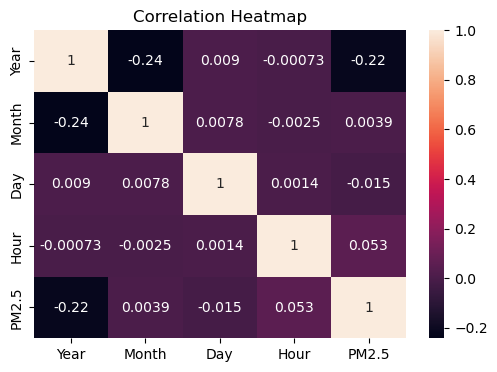

In [34]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Year','Month','Day','Hour','PM2.5']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Trend Smoothing:
* Smoothing (rolling average) is a technique used to remove small fluctuations (noise) from data and show the clear trend.

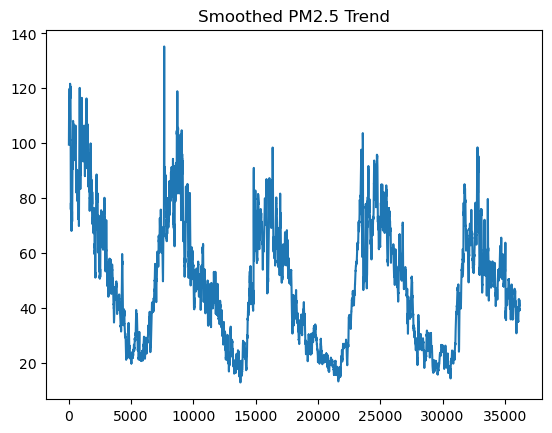

In [35]:
df['PM2.5'].rolling(window=24).mean().plot()
plt.title("Smoothed PM2.5 Trend")
plt.show()